# 03 - Exploratory Data Analysis

## Objective

The purpose of this notebook is to understand the factors associated with customer churn.

The analysis focuses on two main questions:

1. How serious is customer churn overall?
2. Which customer characteristics and services are associated with higher churn?

The findings from this analysis will later help guide feature engineering and model interpretation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [4]:
df.shape

(7043, 22)

In [5]:
churn_counts = df["Churn"].value_counts()

churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
churn_rate = df["ChurnFlag"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


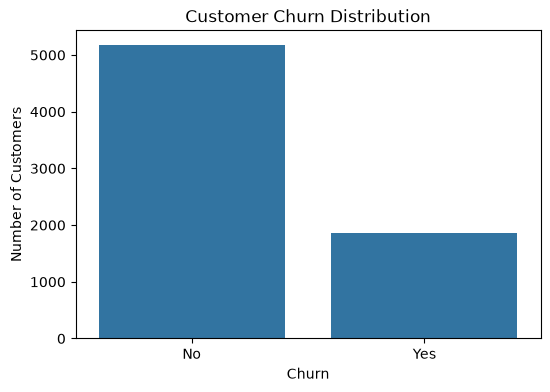

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Business Insight

Approximately 26.5% of customers in the dataset have churned.

Although the majority of customers remain with the company, more than one in four customers leaving represents a meaningful retention problem.

The target variable is also moderately imbalanced, since non-churn customers are much more common than churn customers. Therefore, model evaluation should not rely only on accuracy.

## Churn by Contract Type

Contract type may influence customer retention because customers with longer contracts are usually more committed to the service.

This analysis compares churn rates across:

- Month-to-month contracts
- One-year contracts
- Two-year contracts

In [9]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [10]:
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

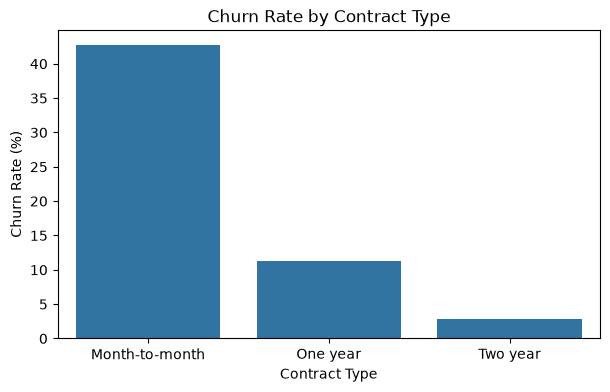

In [11]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

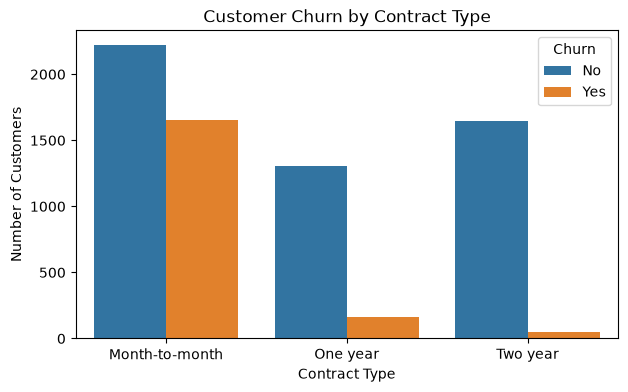

In [12]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Contract type has a strong relationship with customer churn.

- Customers on month-to-month contracts have the highest churn rate at approximately 42.7%.
- Customers on one-year contracts have a much lower churn rate of approximately 11.3%.
- Customers on two-year contracts have the lowest churn rate at approximately 2.8%.

This suggests that customers with longer-term contracts are substantially less likely to churn.

From a business perspective, the company could focus retention campaigns on month-to-month customers and offer incentives for customers to move toward longer-term contracts.

However, this analysis shows association rather than proving that contract type directly causes churn.

In [18]:
contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

## Churn by Customer Tenure

Customer tenure represents the number of months a customer has stayed with the company.

Analyzing tenure helps determine whether churn is concentrated among newer customers or long-term customers.

In [19]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


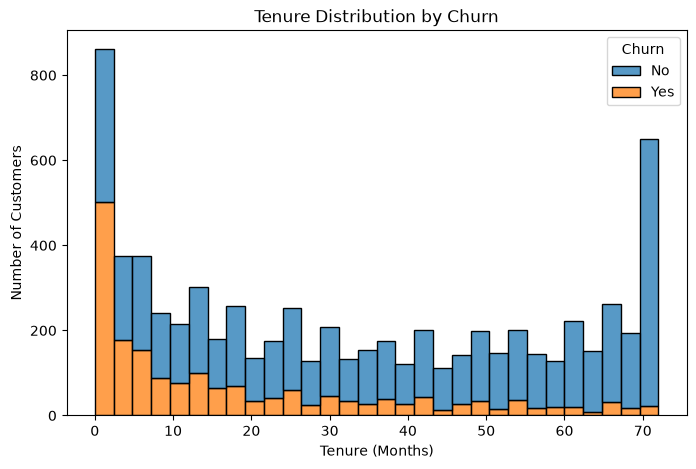

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

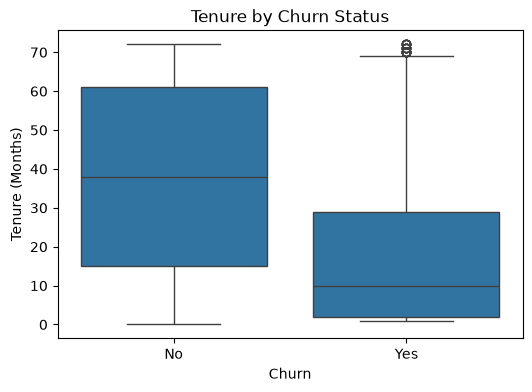

In [21]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()